In [80]:
!poetry run python -m spacy download pt_core_news_sm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 9.7 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 24.3.1 -> 25.1
[notice] To update, run: pip install --upgrade pip
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')



# ORGANIZE LIKE THIS
## 1. Data Collection

Data collection is the first and crucial step in the pipeline, where we gather raw text data from various sources. The quality and quantity of this data can significantly impact the effectiveness of your NLP model.

## 2. Text Cleaning

In this stage, we clean the collected data by removing noise such as HTML tags, emojis, punctuation marks, etc., which do not contribute to understanding the actual content. This cleaned-up data will improve the model's performance and save computational resources.

## 3. Preprocessing

Preprocessing involves transformation to ready the data for feature extraction, including tasks like tokenization (splitting text into words or phrases), stemming/lemmatization (reducing words to their base/root form), and removing stop words (common words like 'is', 'an', 'the' that don't carry much meaning).

## 4. Feature Extraction

This stage involves converting preprocessed data into a format that can be understood by machine learning algorithms. Techniques like Bag-of-Words or TF-IDF (Term Frequency-Inverse Document Frequency) are employed here to create numerical representations of the text.

### 1 - Coleta de dados

In [70]:
dnd5rulebooklink = "https://ordempendragon.wordpress.com/wp-content/uploads/2017/04/dd-5e-livro-do-jogador-fundo-branco-biblioteca-c3a9lfica.pdf"

import requests

# Link do PDF e caminho local para salvar
pdf_url = "https://ordempendragon.wordpress.com/wp-content/uploads/2017/04/dd-5e-livro-do-jogador-fundo-branco-biblioteca-c3a9lfica.pdf"
pdf_path = "dd5e_livro_jogador.pdf"
output_md_path = "spells_dnd5e.md"

# Baixar o PDF
response = requests.get(pdf_url)
with open(pdf_path, "wb") as f:
    f.write(response.content)


In [2]:
from PyPDF2 import PdfReader

# Caminhos
pdf_path = "dd5e_livro_jogador.pdf"
output_md_path = "spells_dnd5e.md"
output_json_path = "spells_dnd5e.json"

# Ler o PDF
reader = PdfReader(pdf_path)

# Extrair o texto cru
extracted_text = ""
spells_pages = []

start_page = 212
end_page = 288

# using this range
# notes para o markdown as paginas com magias estao no intervalo 213-288 de paginas por isso foi necessario usar esse range
for i in range(start_page, end_page):  # 213-288 inclusive
    page = reader.pages[i]
    text = page.extract_text()
    if text:
        text = text.strip()
        extracted_text += text + "\n\n"

with open(output_md_path, "w", encoding="utf-8") as f:
    f.write(extracted_text)

print("Arquivos salvos sem formatação extra.")


Arquivos salvos sem formatação extra.


In [3]:
import re

with open("spells_dnd5e.md", "r", encoding="utf-8") as f:
    lines = f.readlines()

new_lines = []
for i in range(len(lines) - 1):
    line = lines[i].rstrip()
    next_line = lines[i + 1].lower()

    # Verifica se a próxima linha parece indicar início da magia
    if "° nível de" in next_line or "truque de" in next_line:
        # Divide a linha atual em: [parte antes do nome] [nome da magia]
        match = re.search(r"^(.*?[\.\!\?])\s*([A-ZÇÃÕÉÊÍÓÚÀÜ]{2,}(?:\s+[A-ZÇÃÕÉÊÍÓÚÀÜ]{2,})*)\s*$", line)
        if match:
            before = match.group(1).strip()
            title = match.group(2).strip()
            new_lines.append(before + "\n")
            new_lines.append(title + "\n")
            continue

    new_lines.append(line + "\n")

# Adiciona a última linha se faltou
if len(lines) > 0:
    new_lines.append(lines[-1])

with open("spells_dnd5e_titulos_corrigidos.md", "w", encoding="utf-8") as f:
    f.writelines(new_lines)

print("Quebra aplicada: nomes de magia extraídos de linhas coladas.")


Quebra aplicada: nomes de magia extraídos de linhas coladas.


In [4]:
import re

# Carrega o texto original
with open("spells_dnd5e_titulos_corrigidos.md", "r", encoding="utf-8") as f:
    lines = f.readlines()

spells_array = []
start_idx = None

# Função que detecta se a linha parece ser um título em maiúsculas
def is_upper_title(line):
    line = line.strip()
    return (
        line.isupper()
        and len(line) > 3
        and not line.isnumeric()
    )

for i in range(1, len(lines)):
    # Detecta início de magia: linha em caps seguida por "nível de" ou "Truque de"
    if is_upper_title(lines[i - 1]) and (
        "° nível de" in lines[i].lower() or "Truque de" in lines[i]
    ):
        if start_idx is not None:
            spells_array.append("".join(lines[start_idx:i - 1]).strip())
        start_idx = i - 1  # começa na linha do nome da magia

# Adiciona o último bloco
if start_idx is not None:
    spells_array.append("".join(lines[start_idx:]).strip())

# Salva com separadores
with open("spells_dnd5e_separado.md", "w", encoding="utf-8") as f:
    f.write("\n\n---\n\n".join(spells_array))

print(f"{len(spells_array)} magias separadas com '---' e salvas em spells_dnd5e_separado.md")





356 magias separadas com '---' e salvas em spells_dnd5e_separado.md


# alguns dos rotulos ficaram com espacos indesejados quando foi feito a extracao do pdf

In [65]:
# Isso foi feito para corrigir erros de digitação comuns que ocorreram durante a extração do texto do PDF.
# Os erros mais frequentes eram espaços indevidos em palavras como "evocação" e "conjuração",
# provavelmente devido a problemas de OCR ou formatação do documento original.

def fix_typos(text):
    # Dicionário de correções
    corrections = {
        r'evoc ação': 'evocação',
        r'co njuração': 'conjuração',
        r'conjuraç ão': 'conjuração',
    }
    
    # Aplica cada correção
    for typo, correction in corrections.items():
        text = re.sub(typo, correction, text, flags=re.IGNORECASE)
    
    return text

# Carrega o arquivo original
with open("spells_dnd5e_separado.md", "r", encoding="utf-8") as f:
    blocks = f.read().split("\n\n---\n\n")

# Aplica as correções em cada bloco
cleaned_blocks = [fix_typos(block) for block in blocks]

# Salva o resultado de volta no mesmo arquivo
with open("spells_dnd5e_separado.md", "w", encoding="utf-8") as f:
    f.write("\n\n---\n\n".join(cleaned_blocks))

print("Correções de erros de digitação aplicadas e arquivo salvo.")


Correções de erros de digitação aplicadas e arquivo salvo.


In [66]:
import re

# o texto de contagem de páginas eh bem inutil da silva, preciso remover as ocorrências dele 

start_page = 212
end_page = 288

# Carregar o texto original
with open("spells_dnd5e_separado.md", "r", encoding="utf-8") as f:
    text = f.read()

# Lista para armazenar ocorrências encontradas
found_occurrences = []

# Regex que pega ocorrências de números de página em qualquer posição, mas isoladas por limites de palavra ou pontuação
for page_num in range(start_page, end_page + 1):
    # Procura o número entre espaços, pontuação ou quebras de linha
    matches = re.findall(rf"(?<!\d)\b{page_num}\b(?!\d)", text)
    if matches:
        found_occurrences.extend([str(page_num)] * len(matches))

# Exibir o que foi encontrado
print(f"{len(found_occurrences)} ocorrências de números de página entre {start_page} e {end_page} detectadas.")
print("Exemplos únicos encontrados:", sorted(set(found_occurrences)))

# Substituir essas ocorrências por string vazia
for page_num in range(start_page, end_page + 1):
    text = re.sub(rf"(?<!\d)\b{page_num}\b(?!\d)", "", text)

# Agora processa os blocos de magia
blocks = text.split("\n\n---\n\n")
cleaned_blocks = []

for block in blocks:
    lines = block.strip().splitlines()
    if len(lines) < 3:
        continue

    # Adiciona vírgulas ao fim das linhas de atributos
    for i in range(2, len(lines)):
        if re.match(r"^(Tempo de Conjuração|Alcance|Componentes|Duração)\s*:", lines[i]):
            lines[i] = lines[i].rstrip() + ","

    cleaned_block = "\n".join(lines).strip()
    cleaned_blocks.append(cleaned_block)

# Salva o texto limpo com blocos separados por ---
with open("spells_dnd5e_limpo.md", "w", encoding="utf-8") as f:
    f.write("\n\n---\n\n".join(cleaned_blocks))

print("Texto limpo salvo em spells_dnd5e_limpo.md")



79 ocorrências de números de página entre 212 e 288 detectadas.
Exemplos únicos encontrados: ['216', '217', '218', '219', '220', '221', '222', '223', '224', '225', '226', '227', '228', '229', '230', '231', '232', '233', '234', '235', '236', '237', '238', '239', '240', '241', '242', '243', '244', '245', '246', '247', '248', '249', '250', '251', '252', '253', '254', '255', '256', '257', '258', '259', '260', '261', '262', '263', '264', '265', '266', '267', '268', '269', '270', '271', '272', '273', '274', '275', '276', '277', '278', '279', '280', '281', '282', '283', '284', '285', '286', '287', '288']
Texto limpo salvo em spells_dnd5e_limpo.md


In [67]:
import re
import csv
# TODO (s4hlo) separar atributos dos textos em novas colunas
# Lê o texto onde cada feitiço está separado por '---'
with open("spells_dnd5e_limpo.md", "r", encoding="utf-8") as f:
    raw = f.read()

# Divide os feitiços pelo separador
blocks = raw.split("\n\n---\n\n")

data = []

for block in blocks:
    lines = block.strip().splitlines()
    if len(lines) < 2:
        continue

    nome = lines[0].strip()

    # Detecta o nível e o tipo
    nivel_linha = lines[1].strip()
    nivel = 0
    tipo = "indefinido"

    if nivel_linha.lower().startswith("truque de"):
        nivel = 0
        tipo = nivel_linha.lower().replace("truque de", "").replace("(ritual)", "").strip()
    else:
        match = re.match(r"(\d+)°\s+nível\s+de\s+(.+)", nivel_linha.lower())
        if match:
            nivel = int(match.group(1))
            tipo = match.group(2).replace("(ritual)", "").strip()

    # O restante é o texto da magia
    texto = "\n".join(lines[2:]).strip()

    data.append({
        "nome": nome,
        "nivel": nivel,
        "tipo": tipo,
        "texto": texto
    })

# Escreve em CSV
with open("spells.csv", "w", encoding="utf-8", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["nome", "nivel", "tipo", "texto"])
    writer.writeheader()
    writer.writerows(data)

print(f"{len(data)} magias exportadas para spells.csv com sucesso.")


356 magias exportadas para spells.csv com sucesso.


### 2 - Limpeza dos Dados

before this part we only prepare the data for gerenate a csv strcuture, the text to be trined it solve was untouched or barely touched

RAFAEL MAGNO FREITAS NUNES

In [93]:

import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import plotly.graph_objects as go
import re

df = pd.read_csv("spells.csv") # main
df

,nome,nivel,tipo,texto
0,ACALMAR E MOÇÕES,2,encantamento,"Tempo de Conjuração: 1 ação,\nAlcance : 18 met..."
1,ADIVINHAÇÃO,4,adivinhação,"Tempo de Conjuração : 1 ação,\nAlcance : Pesso..."
2,AJUDA,2,abjuração,"Tempo de Conjuração: 1 ação,\nAlcance : 9 metr..."
3,ALARME,1,abjuração,"Tempo de Conjuração: 1 minuto,\nAlcance : 9 me..."
4,ALIADO PLANAR,6,conjuração,"Tempo de Conjuração: 10 minutos,\nAlcance : 18..."
...,...,...,...,...
351,VISÃO DA VERDADE,6,adivinhação,"Tempo de Conjuração: 1 ação,\nAlcance : Toque,..."
352,VISÃO NO ESCURO,2,transmutação,"Tempo de Conjuração: 1 ação,\nAlcance : Toque,..."
353,VITALIDADE FALSA,1,necromancia,"Tempo de Conjuração: 1 ação,\nAlcance : Pessoa..."
354,ZOMBARIA VICIOSA,0,encantamento,"Tempo de Conjuração: 1 ação,\nAlcance : 18 met..."


In [94]:
def make_lowercase(text: str) -> str:
    return text.lower()

def remove_excessive_whitespace(text: str) -> str:
    return re.sub(r"\s+", " ", text).strip()

def remove_break_lines(text: str) -> str:
    return re.sub(r"\n", " ", text).strip()

def remove_whitespace_before_punctuation(text: str) -> str:
    return re.sub(r"\s+([.,!?:])", r"\1", text).strip()

pipeline_clean_text = Pipeline(
    steps=[
        ("make_lowercase", FunctionTransformer(make_lowercase, validate=False)),
        ("remove_excessive_whitespace", FunctionTransformer(remove_excessive_whitespace, validate=False)),
        ("remove_break_lines", FunctionTransformer(remove_break_lines, validate=False)),
        ("remove_whitespace_before_punctuation", FunctionTransformer(remove_whitespace_before_punctuation, validate=False)),
    ]
)



df["texto"] = df["texto"].apply(pipeline_clean_text.transform)
test_cleaned = df["texto"].apply(pipeline_clean_text.transform)
test_cleaned.str.split().apply(len).describe()



count    356.000000
mean     175.519663
std      113.099369
min       33.000000
25%      101.000000
50%      144.500000
75%      212.500000
max      732.000000
Name: texto, dtype: float64

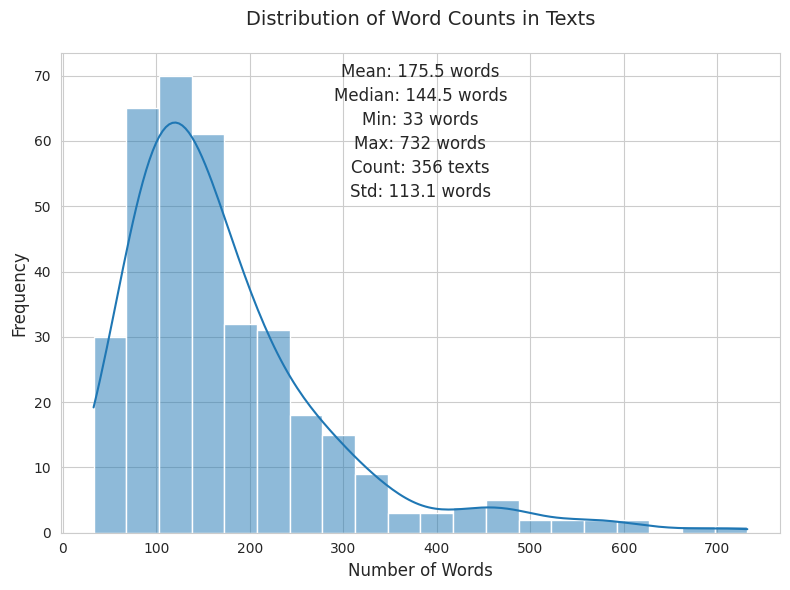

In [95]:
def plot_word_count_distribution(text_series, figsize=(8, 6)):
    """
    Plot a histogram of word counts with key statistics.
    
    Args:
        text_series (pd.Series): Series containing text data
        figsize (tuple): Figure size (width, height)
    """
    plt.figure(figsize=figsize)
    sns.set_style("whitegrid")

    # Get the word count statistics
    word_counts = text_series.str.split().apply(len)
    stats = word_counts.describe()

    # Create a simple histogram
    sns.histplot(word_counts, bins=20, kde=True)
    plt.title("Distribution of Word Counts in Texts", fontsize=14, pad=20)
    plt.xlabel("Number of Words", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)

    # Add text annotations for key statistics
    plt.text(0.5, 0.95, f"Mean: {stats['mean']:.1f} words", 
             transform=plt.gca().transAxes, ha='center', fontsize=12)
    plt.text(0.5, 0.9, f"Median: {stats['50%']:.1f} words", 
             transform=plt.gca().transAxes, ha='center', fontsize=12)
    plt.text(0.5, 0.85, f"Min: {stats['min']:.0f} words", 
             transform=plt.gca().transAxes, ha='center', fontsize=12)
    plt.text(0.5, 0.8, f"Max: {stats['max']:.0f} words", 
             transform=plt.gca().transAxes, ha='center', fontsize=12)
    plt.text(0.5, 0.75, f"Count: {stats['count']:.0f} texts", 
             transform=plt.gca().transAxes, ha='center', fontsize=12)
    plt.text(0.5, 0.7, f"Std: {stats['std']:.1f} words", 
             transform=plt.gca().transAxes, ha='center', fontsize=12)

    plt.tight_layout()
    plt.show()

# Example usage:
plot_word_count_distribution(test_cleaned)



In [78]:

def plot_histogram_word(text_list, n_most_common=30, sufix=""):
    words = [word for txt in text_list for word in txt.split()]

    word_counts = Counter(words)

    top_words = dict(word_counts.most_common(n_most_common))

    fig = go.Figure(
        [
            go.Bar(
                x=list(top_words.keys()),
                y=list(top_words.values()),
                text=list(top_words.values()),
                textposition="auto",
            )
        ]
    )
    fig.update_layout(
        title_text=f"Top {n_most_common} most frequent words in the text {sufix}",
        title_x=0.5,
        xaxis_title="Words",
        yaxis_title="Frequency",
        xaxis_tickangle=-45,
    )
    fig.show()

plot_histogram_word(test_cleaned, 40, " with stopwords ")

Unique tipo types:


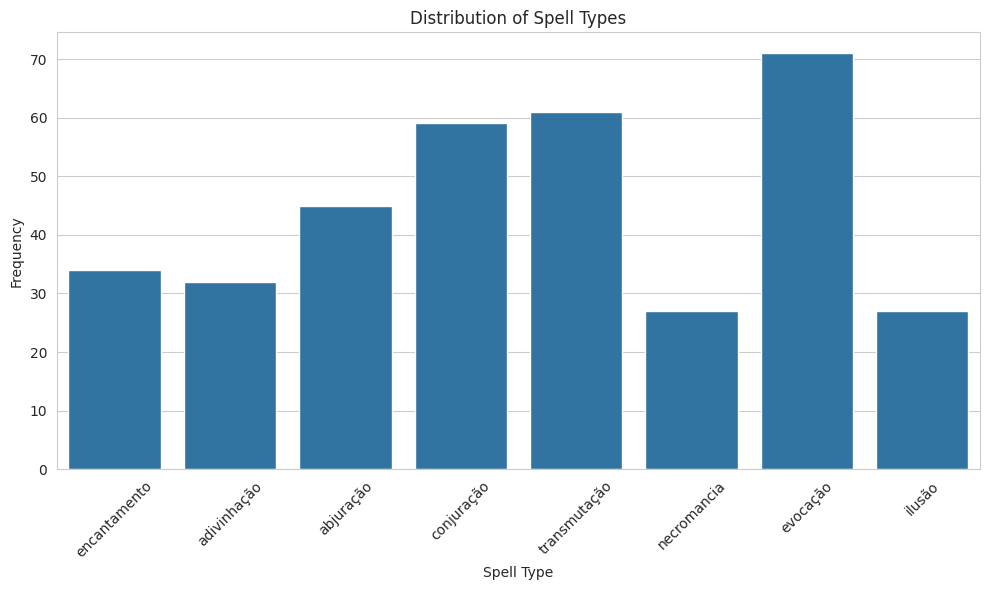

In [86]:

def plot_spell_types_distribution(df, target_column):
    unique_tipos = df[target_column].unique()
    print(f"Unique {target_column} types:")
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=target_column)
    plt.title("Distribution of Spell Types")
    plt.xlabel("Spell Type")
    plt.ylabel("Frequency")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


plot_spell_types_distribution(df, "tipo")


## 3 - pre processamento


In [88]:
# lista de textos, apos a aplicado a limpeza, as etapas de pre processamentos serao em cima desta lista
import spacy
import nltk
from nltk.corpus import stopwords

test_cleaned

0      tempo de conjuração: 1 ação, alcance: 18 metro...
1      tempo de conjuração: 1 ação, alcance: pessoal,...
2      tempo de conjuração: 1 ação, alcance: 9 metros...
3      tempo de conjuração: 1 minuto, alcance: 9 metr...
4      tempo de conjuração: 10 minutos, alcance: 18 m...
                             ...                        
351    tempo de conjuração: 1 ação, alcance: toque, c...
352    tempo de conjuração: 1 ação, alcance: toque, c...
353    tempo de conjuração: 1 ação, alcance: pessoal,...
354    tempo de conjuração: 1 ação, alcance: 18 metro...
355    tempo de conjuração: 1 ação, alcance: 18 metro...
Name: texto, Length: 356, dtype: object

In [110]:
import spacy
import nltk
from nltk.corpus import stopwords

# Baixe os stopwords do nltk se necessário
nltk.download("stopwords")

# Carrega modelo spaCy em português
nlp = spacy.load("pt_core_news_sm")

def remove_combined_stopwords(text_series, use_spacy_tokenizer=True):
    """
    Remove stopwords combinadas de nltk e spaCy de uma Series de texto.
    Retorna listas de tokens (não strings).
    """

    # Stopwords de spaCy
    stopwords_spacy = nlp.Defaults.stop_words

    # Stopwords de nltk (Português)
    stopwords_nltk = set(stopwords.words("portuguese"))

    # União das duas listas
    combined_stopwords = stopwords_spacy.union(stopwords_nltk)

    def clean_text(text):
        tokens = text.split()
        return [t for t in tokens if t.lower() not in combined_stopwords]

    def clean_text_spacy_tokenize(text):
        doc = nlp(text)
        return [
            token.text.lower()
            for token in doc
            if not token.is_punct
            and not token.is_space
            and token.text.lower() not in combined_stopwords
        ]

    if use_spacy_tokenizer:
        return text_series.apply(clean_text_spacy_tokenize)
    else:
        return text_series.apply(clean_text)


txts_train_cleaned_no_stopwords = remove_combined_stopwords(test_cleaned, True)
txts_joined = txts_train_cleaned_no_stopwords.apply(lambda tokens: " ".join(tokens))
plot_histogram_word(txts_joined, 30, "without stopwords")



[nltk_data] Downloading package stopwords to
[nltk_data]     /home/sleight/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


AttributeError: 'list' object has no attribute 'split'

In [107]:
nlp = spacy.load("pt_core_news_sm")

def tokenize_series(series: pd.Series) -> pd.Series:
    """
    Tokeniza uma Series de strings usando spaCy.
    Retorna uma nova Series com listas de tokens.
    """
    return series.apply(lambda text: [token.text for token in nlp(text) if not token.is_space])
tokens_series = tokenize_series(test_cleaned)
tokens_series


0      [tempo, de, conjuração, :, 1, ação, ,, alcance...
1      [tempo, de, conjuração, :, 1, ação, ,, alcance...
2      [tempo, de, conjuração, :, 1, ação, ,, alcance...
3      [tempo, de, conjuração, :, 1, minuto, ,, alcan...
4      [tempo, de, conjuração, :, 10, minutos, ,, alc...
                             ...                        
351    [tempo, de, conjuração, :, 1, ação, ,, alcance...
352    [tempo, de, conjuração, :, 1, ação, ,, alcance...
353    [tempo, de, conjuração, :, 1, ação, ,, alcance...
354    [tempo, de, conjuração, :, 1, ação, ,, alcance...
355    [tempo, de, conjuração, :, 1, ação, ,, alcance...
Name: texto, Length: 356, dtype: object

/home/sleight/.cache/pypoetry/virtualenvs/pln-qWjcxHse-py3.10/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/home/sleight/.cache/pypoetry/virtualenvs/pln-qWjcxHse-py3.10/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



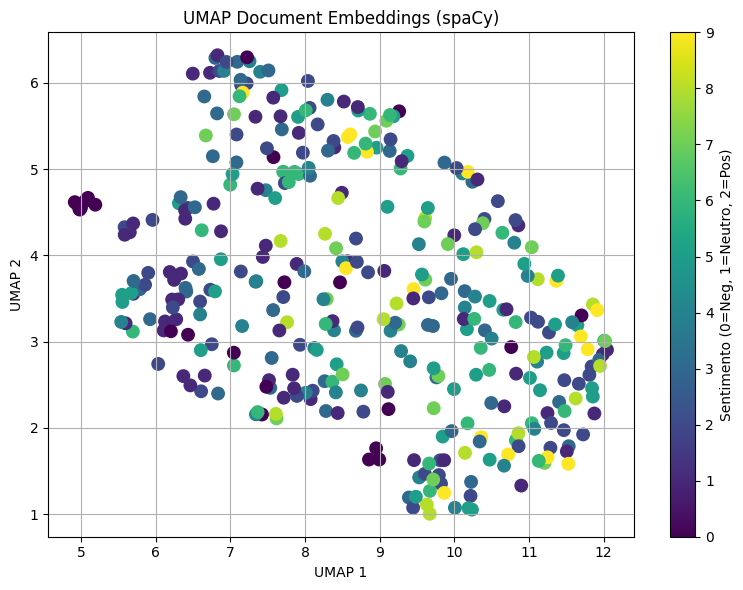

In [164]:
import spacy
import numpy as np
import umap

nlp = spacy.load("pt_core_news_md")

df["embedding"] = df["texto"].apply(lambda x: nlp(x).vector)

X = np.vstack(df["embedding"].values)
y = df["nivel"].values

X_umap = umap.UMAP(random_state=42).fit_transform(X)

# Plot
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y,  s=80)
plt.title("UMAP Document Embeddings (spaCy)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.colorbar(scatter, label="Sentimento (0=Neg, 1=Neutro, 2=Pos)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [161]:
import plotly.express as px
import pandas as pd
import spacy
import numpy as np
import umap
import textwrap

# Embedding com spaCy
nlp = spacy.load("pt_core_news_md")
df["embedding"] = df["texto"].apply(lambda x: nlp(x).vector)
X = np.vstack(df["embedding"].values)

# UMAP
X_umap = umap.UMAP(random_state=42).fit_transform(X)

# Adiciona coordenadas ao DataFrame
df["umap_x"] = X_umap[:, 0]
df["umap_y"] = X_umap[:, 1]

# Formata o texto para hover com quebras de linha
df["texto_hover"] = df["texto"].apply(lambda t: "<br>".join(textwrap.wrap(t, width=80)))

# Gráfico interativo com Plotly
fig = px.scatter(
    df,
    x="umap_x",
    y="umap_y",
    color="tipo",  # ou "tipo"
    hover_name="nome",
    hover_data={
        "nivel": True,
        "tipo": True,
        "texto_hover": True,
        "texto": False,
        "umap_x": False,
        "umap_y": False
    },
    title="Embeddings de Magias (UMAP + spaCy)",
    labels={"nivel": "Nível da magia"},
    width=900,
    height=700
)

fig.show()


/home/sleight/.cache/pypoetry/virtualenvs/pln-qWjcxHse-py3.10/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/home/sleight/.cache/pypoetry/virtualenvs/pln-qWjcxHse-py3.10/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



pos coleta de dados - tratamento